# 01 — The Perceptron

The perceptron is the simplest neural network: a single neuron.

## Our problem: will the student pass?

We want to predict whether a student passes an exam based on two inputs:
- $x_1$ — hours of study
- $x_2$ — hours of sleep

**Step 1 — Weighted sum:**

$$z = (x_1 \times w_1) + (x_2 \times w_2) + b$$

Each input $x_i$ is multiplied by its weight $w_i$ — how important that factor is.
All products are summed, then a bias $b$ is added.

This can be written compactly as a dot product:

$$z = \mathbf{w} \cdot \mathbf{x} + b$$

**Step 2 — Activation function:**

$$\hat{y} = f(z)$$

The function $f$ transforms $z$ into a decision: 0 (fails) or 1 (passes).

## Variables

| Symbol | Name | Role |
|---|---|---|
| $x_1$ | study hours | first input |
| $x_2$ | sleep hours | second input |
| $w_i$ | weight | importance of each input |
| $b$ | bias | shifts the decision boundary |
| $z$ | weighted sum | raw output before activation |
| $\hat{y}$ | prediction | 0 = fails, 1 = passes |

In [44]:
import numpy as np
import matplotlib.pyplot as plt

In [45]:
# A perceptron: single neuron, forward pass
def perceptron(x, w, b):
    z = np.dot(w, x) + b
    return z

# Example: a student who studied 3 hours and slept 6 hours
x = np.array([3, 6])    # study hours, sleep hours
w = np.array([0.4, -0.3])  # weights (random initialization)
b = 0.1                     # bias

z = perceptron(x, w, b)
print(f"Study: {x[0]}h  Sleep: {x[1]}h")
print(f"Weighted sum z = {z:.4f}")

Study: 3h  Sleep: 6h
Weighted sum z = -0.5000


In [46]:
# Step activation function

def step_activation(z):
    return 1 if z > 0 else 0

prediction = step_activation(z)
print(f"z = {z:.4f} -- prediction = {prediction}")

z = -0.5000 -- prediction = 0


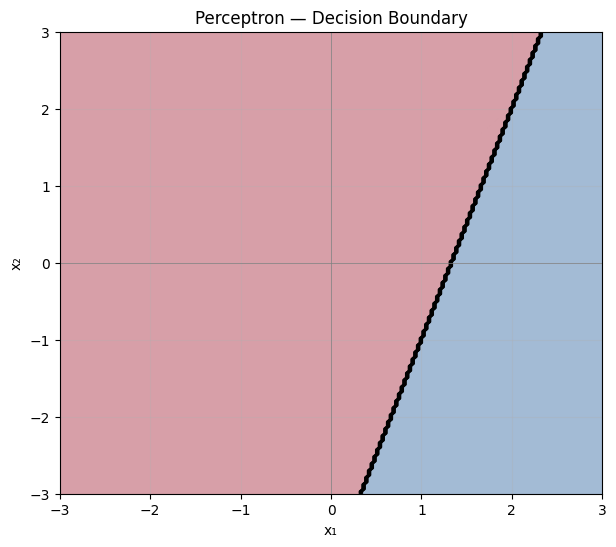

In [47]:
# Visualizing the decision boundary of a perceptron
# Using only 2 inputs so we can plot in 2D

def perceptron_2d(x1, x2, w1, w2, b):
    z = x1*w1 + x2*w2 + b
    return step_activation(z)

w1, w2, b = 3, -1, -4

# Generate a grid of points
x1_vals = np.linspace(-3, 3, 200)
x2_vals = np.linspace(-3, 3, 200)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Classify each point
Z = np.array([[perceptron_2d(x1, x2, w1, w2, b) 
               for x1 in x1_vals] 
               for x2 in x2_vals])

# Plot
plt.figure(figsize=(7, 6))
plt.contourf(X1, X2, Z, alpha=0.4, cmap='RdBu')
plt.contour(X1, X2, Z, colors='black', linewidths=1.5)
plt.title('Perceptron — Decision Boundary')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_1111/960967959.py:15: RuntimeWarning: divide by zero encountered in divide
  x2_line = (-w1 * x1_vals - b) / w2


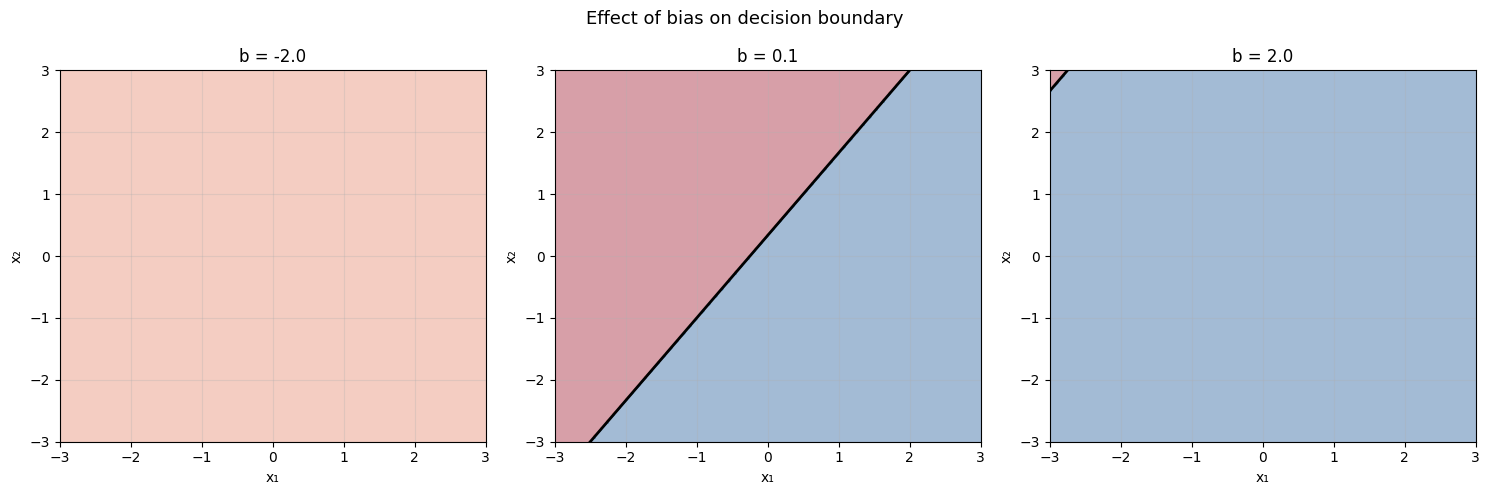

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

configs = [
    (0.4, -0., -2.0, "b = -2.0"),
    (0.4, -0.3,  0.1, "b = 0.1"),
    (0.4, -0.3,  2.0, "b = 2.0"),
]

for ax, (w1, w2, b, title) in zip(axes, configs):
    Z = np.array([[perceptron_2d(x1, x2, w1, w2, b)
                   for x1 in x1_vals]
                   for x2 in x2_vals])
    
    # Decision boundary line
    x2_line = (-w1 * x1_vals - b) / w2
    
    ax.contourf(X1, X2, Z, alpha=0.4, cmap='RdBu')
    ax.plot(x1_vals, x2_line, 'k-', linewidth=2)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title(title)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of bias on decision boundary', fontsize=13)
plt.tight_layout()
plt.show()

## Learning Rule

The perceptron updates its weights only when it makes a mistake.

$$w_i \leftarrow w_i + \eta \cdot (y - \hat{y}) \cdot x_i$$
$$b \leftarrow b + \eta \cdot (y - \hat{y})$$

Where:
- $\eta$ (eta) — learning rate: how big the adjustment is
- $y$ — real label (0 or 1)
- $\hat{y}$ — prediction (0 or 1)
- $(y - \hat{y})$ — error: 0 if correct, ±1 if wrong

In [49]:
#Learning Rule

def train_perceptron(X, y, lr=0.1, epochs=10):
    #1. Initialize weights to zero and bias to zero
    w = np.zeros(X.shape[1])
    b = 0.0

    #W = [w1, w2] = [0.0, 0.0]  # al inicio

    for epoch in range(epochs):
        for xi, yi in zip(X, y):
            z = np.dot(w, xi) + b
            y_prediction = step_activation(z)
            error = yi - y_prediction
            #Learnin Rule
            w = w + lr * error * xi
            b = b + lr * error
    return w, b

# Student Example
X = np.array([[1,3], [2, 4], [3, 6], [4, 7]])

y = np.array([0, 0, 1, 1])

# Normalization
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_normalized = (X - X_min)/(X_max - X_min)

w, b = train_perceptron(X_normalized, y)
print(f"Final Weights: {w}")
print(f"Final Bias: {b}")
            

Final Weights: [0.06666667 0.1       ]
Final Bias: -0.1


In [50]:
# Verify Prediction
labels = ["Fails", "Passes"]

for xi, yi in zip(X_normalized, y):
    z = np.dot(w, xi) + b
    y_prediction = step_activation(z)
    status = "correct" if y_prediction == yi else "incorrect"
    print(f"Study: {xi[0]}h - Sleep: {xi[1]}h --- {labels[y_prediction]} {status}")

Study: 0.0h - Sleep: 0.0h --- Fails correct
Study: 0.3333333333333333h - Sleep: 0.25h --- Fails correct
Study: 0.6666666666666666h - Sleep: 0.75h --- Passes correct
Study: 1.0h - Sleep: 1.0h --- Passes correct


In [51]:
for i, (xi, yi) in enumerate(zip(X_normalized, y)):
    z = np.dot(w, xi) + b
    y_prediction = step_activation(z)
    status = "correct" if y_prediction == yi else "incorrect"
    print(f"Study: {X[i][0]}h - Sleep: {X[i][1]}h --- {labels[y_prediction]} {status}")

Study: 1h - Sleep: 3h --- Fails correct
Study: 2h - Sleep: 4h --- Fails correct
Study: 3h - Sleep: 6h --- Passes correct
Study: 4h - Sleep: 7h --- Passes correct
